In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import sys
sys.path.append('.')

from utils import *
from experiment import *
from dataloader.vlfc import COMPANIES
from visualize import *

# Quick start with a single experiment

We start with runing a single time series forecasting experiment. We will run return forecasting problem on AMD stock return with baseline adapative conformal inference (ACI) methods.

### Load the hyper parameters of the model

The first step is to load the config file in `bellman-conformal-inference/config`.

In [2]:
params = read_yaml('config/rtfc-aci-AMD.yaml')

The naming of the config file follows the convention of `TASK_NAME-METHOD_NAME-TASK_DATASET.yaml`. In this case, the config file looks like

```
> params

{'task': 'rtfc',        # the return forecasting problem, avalibale choices ['rtfc', 'vlfc']
 'method': 'aci',       # the adapative conformal algorithm to use. 'aci' means baseline Adapative Conformal Algorithm
 'id': 'AMD',           # the dataset to be used by the experiment. They can be found in 'data/'
 'alpha0': 0.1,         # target miscoverage rate. In this case 10%
 'gamma': 0.1,          # step size for either ACI or BCI
 'lambda_init': 0.9,
 'lambda_max': 1.0,
 'lambda_min': 0.0}
```

We can run the experiment by using the `.run()` method, which captures all the details of computing $\alpha_t$ for each $t$. To hack around the code, please see `experiment.py` for the logic of computing $\alpha_t$.

### Build the experiment object and run the experiment

The experiment object created by

In [3]:
exp = ForecastingExperiment(params)

In [4]:
exp.run()

2026-03-02 11:56:26,257 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED


2026-03-02 11:56:28,674 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.4171392917633057s


After we run the experiment, we can optionally save the experiment. They will be saved in `bellman-conformal-inference/result/*`. This include the full trajectory of the experiment, and the hyper parameter used.

In [5]:
exp.save()

Finally, we can visualize the experiment by calling the `visualize_single_exp(**)` function defined in `bellman-conformal-inference/visualize.py`.

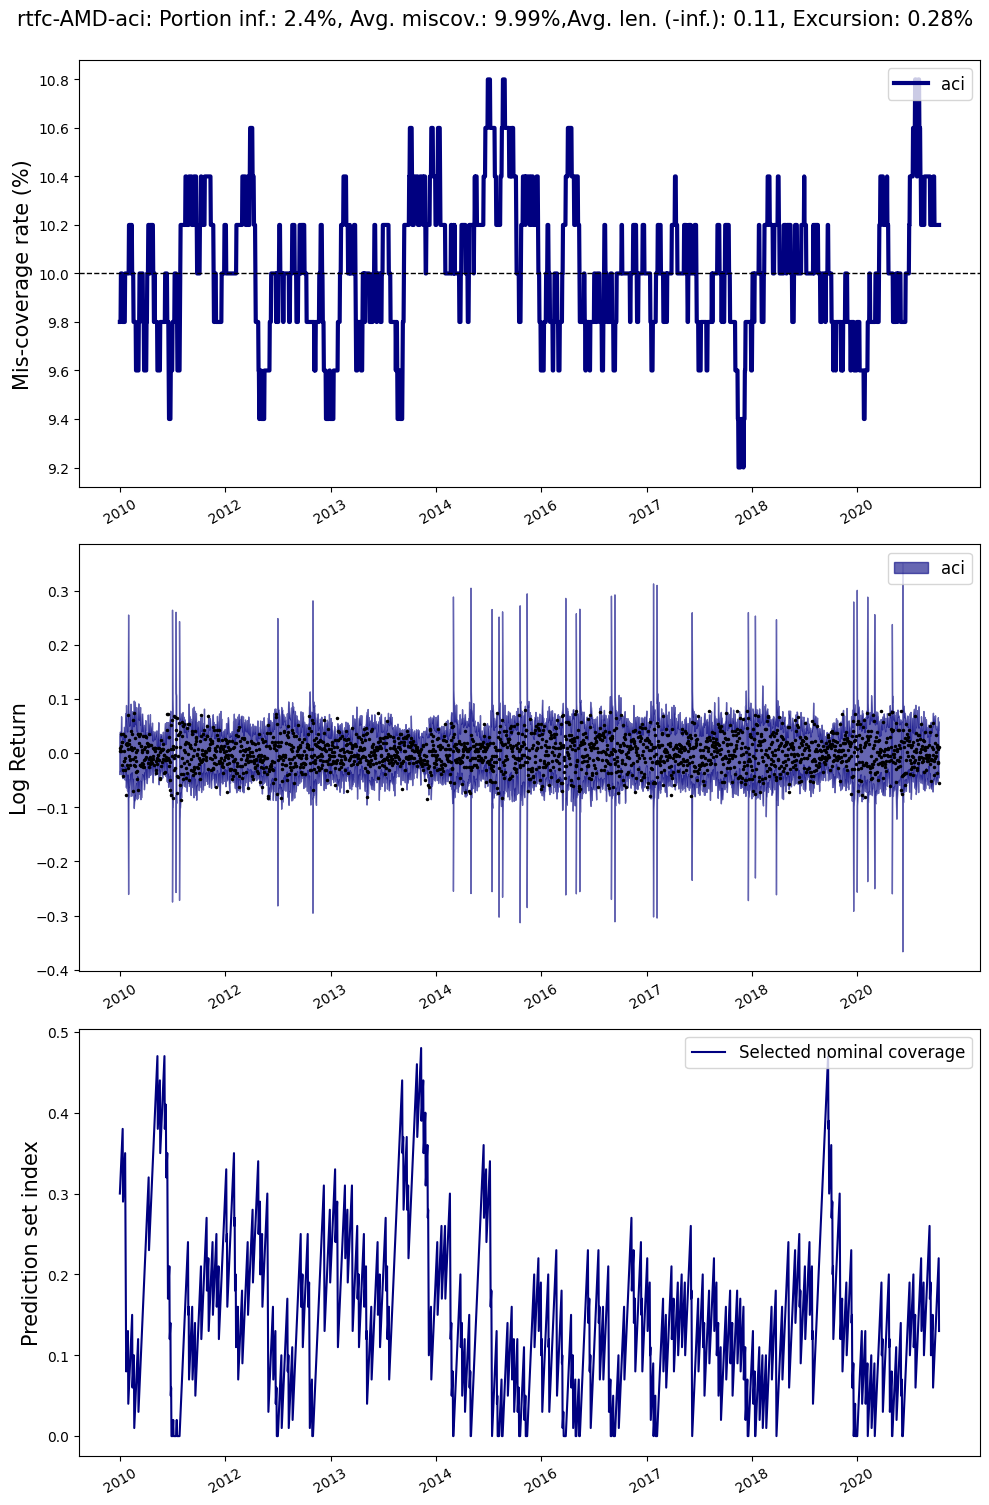

In [6]:
visualize_single_exp(exp.params, exp.result)

# Comparsion of three experiments

Next we demonstrate how to compare performance across three methods -- ACI, BCI, fixed $\alpha_t$ for the same experiment.

In [7]:
exp_aci = ForecastingExperiment(read_yaml('config/rtfc-aci-AMD.yaml'))
exp_aci.run()

exp_bci = ForecastingExperiment(read_yaml('config/rtfc-bci-AMD.yaml'))
exp_bci.run()

exp_fixed = ForecastingExperiment(read_yaml('config/rtfc-fixed-AMD.yaml'))
exp_fixed.run()

2026-03-02 11:56:34,027 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-03-02 11:56:36,575 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.5486810207366943s
2026-03-02 11:56:36,583 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-03-02 11:56:45,131 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 8.54807996749878s
2026-03-02 11:56:45,139 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED
2026-03-02 11:56:47,365 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.2262301445007324s


As before, we can visualize the comparsion as `visualize_three_exp`. In contrast to the previous plot, the figure first panel is the moving average mis-coverage rate, and the bottom panel is the moving average of interval length. The performance metric is given in the title of the plot:

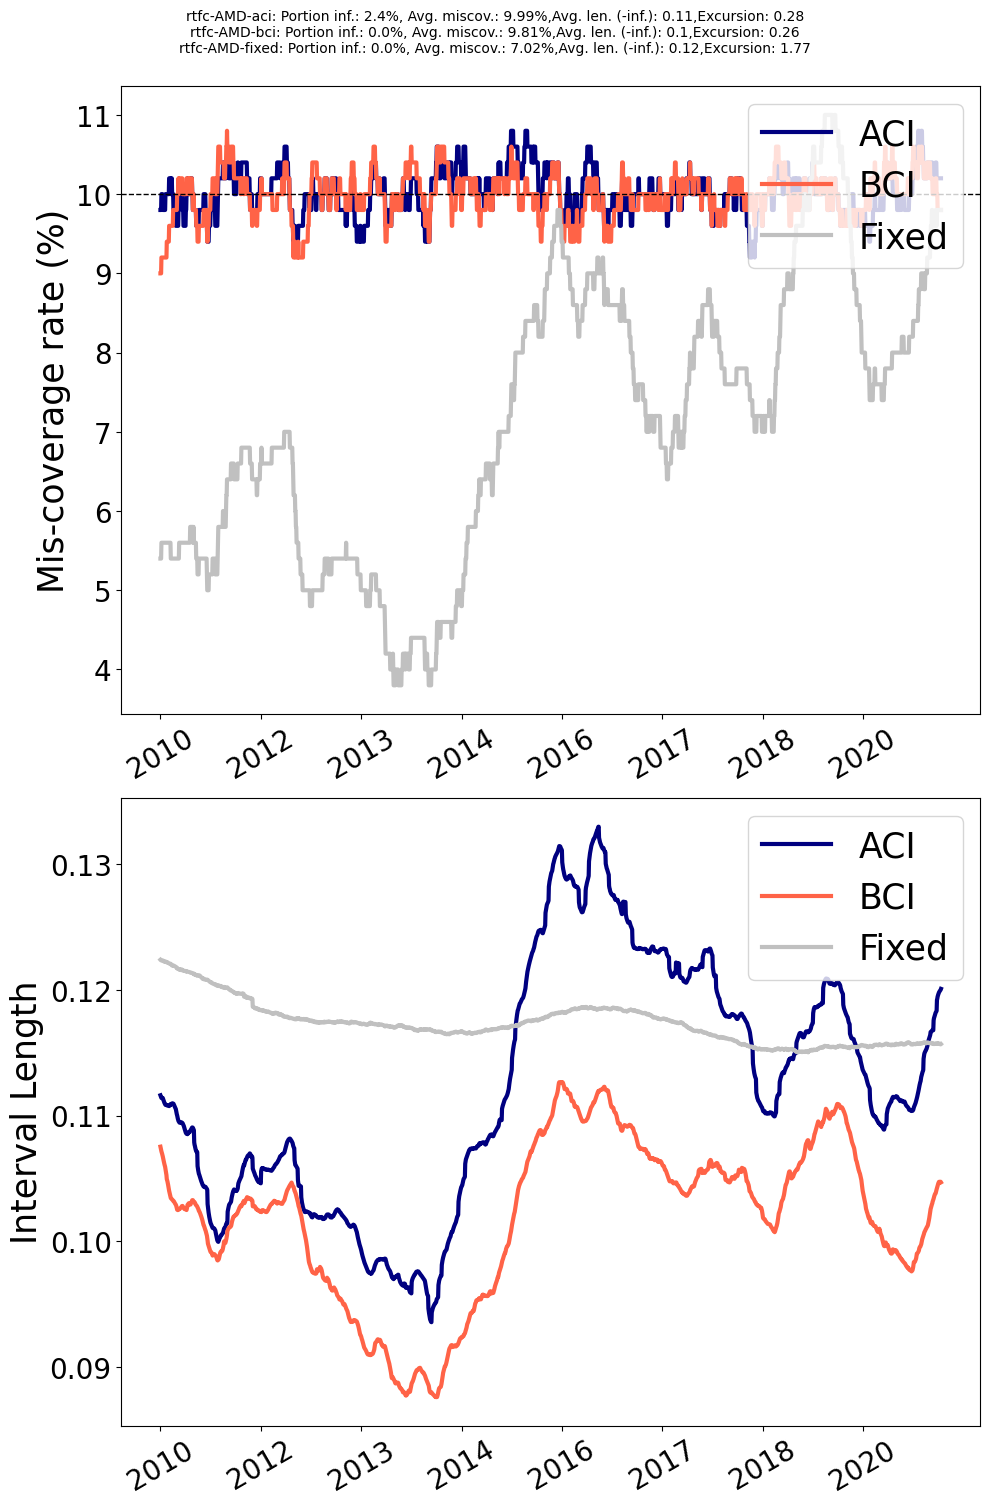

In [8]:
visualize_three_exp(exp_aci.params, exp_aci.result,
                    exp_bci.params, exp_bci.result,
                    exp_fixed.params, exp_fixed.result)

In [1]:
import numpy as np
import pandas as pd
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

sys.setrecursionlimit(10000)

# =============================================================================
# METRICS & HELPERS
# =============================================================================

def compute_metrics(result_df, task):
    """Compute Miscoverage %, Volatility (Std %), and Avg Length"""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta  = pd.to_numeric(result_df['beta'],  errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')

    err_ind      = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    miscov       = err_ind.mean()
    std          = local_miscov.std()

    if task == 'vlfc':
        raw_lengths = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    else:
        raw_lengths = upper - lower

    valid = raw_lengths[np.isfinite(raw_lengths)]
    length = valid.mean() if len(valid) > 0 else np.nan
    return float(miscov), float(std), float(length)

def estimate_lambda_max(task, dataset, warmup=100):
    """Run BCI to get the 99th percentile of lambda over the first 100 periods."""
    try:
        cfg = read_yaml(f'config/{task}-bci-{dataset}.yaml')
    except FileNotFoundError:
        cfg = read_yaml(f'config/{task}-bci.yaml')
        cfg['id'] = dataset
        
    exp = ForecastingExperiment(cfg)
    exp.run()
    lambdas = pd.to_numeric(exp.result['lambda'], errors='coerce').dropna()
    if len(lambdas) == 0:
        return 1.0
    vals = lambdas.values[:warmup] if len(lambdas) >= warmup else lambdas.values
    return float(max(np.percentile(vals, 99), 1.0))

# =============================================================================
# PID BINARY SEARCH
# =============================================================================

def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true, task):
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta, Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        if task == 'vlfc':
            upper = (y_pred_center + q)**2
            lower = np.maximum(y_pred_center - q, 0)**2
        else:
            upper = y_pred_center + q
            lower = y_pred_center - q
            
        is_covered = (y_true >= lower) & (y_true <= upper)
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        return var, True, q
    except Exception:
        return 1e10, False, None

def binary_search_pid(scores, y_pred_center, y_true, csat, ki, target_std, task):
    """Tune eta to match ACI's variance (std^2)"""
    target_var = target_std ** 2
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    lo, hi = 1e-6, bound_5B
    best_eta, best_diff, best_q = lo, 1e10, None

    for _ in range(25):
        mid = np.sqrt(lo * hi)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true, task)
        if not valid:
            hi = mid
            continue

        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff, best_eta, best_q = diff, mid, q

        if var > target_var:
            lo = mid
        else:
            hi = mid
    return best_eta, best_q

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    suites = [
        {'task': 'trend', 'datasets': ['google_trends']},
        {'task': 'vlfc',  'datasets': ['AMD', 'Amazon', 'Nvidia']},
        {'task': 'rtfc',  'datasets': ['AMD', 'Amazon', 'Nvidia']}
    ]

    base_gamma = 0.1
    T_vals = [1, 3, 5, 7]
    c_vals = [0.01, 0.05, 0.1, 0.2, 0.5]
    
    # Store results for the final tables
    table_1_results = []
    table_2_results = []

    for suite in suites:
        task = suite['task']
        for dataset in suite['datasets']:
            print(f"\nProcessing {task.upper()} - {dataset}...")

            # 1. Fixed Baseline (Required to extract scores for PID)
            try:
                exp_fixed = ForecastingExperiment(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
            except FileNotFoundError:
                cfg_fix = read_yaml(f'config/{task}-fixed.yaml')
                cfg_fix['id'] = dataset
                exp_fixed = ForecastingExperiment(cfg_fix)
            exp_fixed.run()

            y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
            u_f = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
            l_f = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
            
            if task == 'vlfc':
                yt = np.sqrt(np.maximum(y_true, 0))
                ut = np.sqrt(np.maximum(u_f, 0))
                lt = np.sqrt(np.maximum(l_f, 0))
            else:
                yt, ut, lt = y_true, u_f, l_f
                
            y_pred_center = (ut + lt) / 2
            scores = np.abs(yt - y_pred_center)
            
            # 2. ACI Baseline (Target Variance)
            try:
                cfg_aci = read_yaml(f'config/{task}-aci-{dataset}.yaml')
            except FileNotFoundError:
                cfg_aci = read_yaml(f'config/{task}-aci.yaml')
                cfg_aci['id'] = dataset
            cfg_aci['gamma'] = base_gamma
            exp_aci = ForecastingExperiment(cfg_aci)
            exp_aci.run()
            aci_m, aci_s, aci_l = compute_metrics(exp_aci.result, task)
            
            table_1_results.append([task.upper(), dataset, f"ACI (gamma={base_gamma})", aci_m*100, aci_s*100, aci_l])

            # 3. PID Binary Search (Matching ACI)
            T_len = len(scores)
            ki = np.percentile(scores, 99) # 99th percentile requirement
            csat = max((2 / np.pi) * (np.ceil(np.log(T_len) * 0.05) - 1 / np.log(T_len)), 0.1)
            
            eta_found, pid_q = binary_search_pid(scores, y_pred_center, y_true, csat, ki, aci_s, task)
            
            df_pid = exp_fixed.result.copy()
            if task == 'vlfc':
                df_pid['upper'] = (y_pred_center + pid_q)**2
                df_pid['lower'] = np.maximum(y_pred_center - pid_q, 0)**2
            else:
                df_pid['upper'] = y_pred_center + pid_q
                df_pid['lower'] = y_pred_center - pid_q
            df_pid['alpha'] = 0.1
            df_pid['beta'] = ((y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])).astype(int)
            pid_m, pid_s, pid_l = compute_metrics(df_pid, task)
            
            table_1_results.append(["", "", "PID", pid_m*100, pid_s*100, pid_l])

            # 4. Estimate lambda_max for BCI
            lambda_max = estimate_lambda_max(task, dataset, warmup=100)
            
            try:
                base_bci_cfg = read_yaml(f'config/{task}-bci-{dataset}.yaml')
            except FileNotFoundError:
                base_bci_cfg = read_yaml(f'config/{task}-bci.yaml')
                base_bci_cfg['id'] = dataset
            
            # --- T-SWEEP (TABLE 1) ---
            # Using a fixed c (e.g., c=0.1) for the T-sweep
            fixed_c_for_t_sweep = 0.1
            derived_gamma_t = fixed_c_for_t_sweep * lambda_max
            
            for t_val in T_vals:
                cfg_bci = dict(base_bci_cfg)
                cfg_bci['lambda_max'] = float(lambda_max)
                cfg_bci['gamma'] = float(derived_gamma_t)
                cfg_bci['T'] = t_val
                
                exp_bci = ForecastingExperiment(cfg_bci)
                exp_bci.run()
                bci_m, bci_s, bci_l = compute_metrics(exp_bci.result, task)
                
                table_1_results.append(["", "", f"BCI (T={t_val})", bci_m*100, bci_s*100, bci_l])

            # --- c-SWEEP (TABLE 2) ---
            # Using a fixed T (e.g., T=3) for the c-sweep
            fixed_t_for_c_sweep = 3
            for c in c_vals:
                derived_gamma_c = c * lambda_max
                cfg_bci = dict(base_bci_cfg)
                cfg_bci['lambda_max'] = float(lambda_max)
                cfg_bci['gamma'] = float(derived_gamma_c)
                cfg_bci['T'] = fixed_t_for_c_sweep
                
                exp_bci = ForecastingExperiment(cfg_bci)
                exp_bci.run()
                bci_m, bci_s, bci_l = compute_metrics(exp_bci.result, task)
                
                table_2_results.append([dataset, c, derived_gamma_c, bci_m*100, bci_s*100, bci_l])

    # =========================================================================
    # PRINT FORMATTED TABLES
    # =========================================================================
    print("\n\n" + "="*80)
    print("Table 1: gamma = 0.1, T Sweep")
    print("="*80)
    print(f"{'Task':<6} {'Dataset':<15} {'Method':<20} {'Miscoverage %':<15} {'Volatility (Std %)':<20} {'Avg Length':<12}")
    print("-" * 90)
    for row in table_1_results:
        print(f"{row[0]:<6} {row[1]:<15} {row[2]:<20} {row[3]:<14.2f}% {row[4]:<19.2f}% {row[5]:<12.4f}")

    print("\n\n" + "="*80)
    print("Table 2: BCI Normalized Gain (c) Sensitivity")
    print("="*80)
    print(f"{'Dataset':<15} {'c Value':<10} {'Derived γ':<15} {'Miscoverage %':<15} {'Volatility (Std %)':<20} {'Avg Length':<12}")
    print("-" * 90)
    for row in table_2_results:
        print(f"{row[0]:<15} {row[1]:<10.2f} {row[2]:<15.4f} {row[3]:<14.2f}% {row[4]:<19.2f}% {row[5]:<12.4f}")

2026-04-19 15:35:58,259 - INFO - Experiment trend-fixed-google_trends-gamma_NA-lambda0_NA STARTED



Processing TREND - google_trends...


TypeError: unsupported operand type(s) for /: 'list' and 'int'

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# HELPER FUNCTIONS & METRICS
# =============================================================================

def clean_config(config):
    new_config = config.copy()
    for key, value in new_config.items():
        if isinstance(value, list):
            new_config[key] = value[0]
    return new_config

def compute_metrics(result_df, task='rtfc'):
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta  = pd.to_numeric(result_df['beta'],  errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')

    err_ind      = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    miscov       = err_ind.mean()
    std          = local_miscov.std()

    if task == 'vlfc':
        raw_lengths = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    else:
        raw_lengths = upper - lower

    valid = raw_lengths[np.isfinite(raw_lengths)]
    length = valid.mean() if len(valid) > 0 else np.nan
    return float(miscov), float(std), float(length)

def compute_initial_miscov(result_df, window=100):
    """Compute average miscoverage in the first `window` steps."""
    df = result_df.iloc[:window].copy()
    alpha = pd.to_numeric(df['alpha'], errors='coerce')
    beta = pd.to_numeric(df['beta'], errors='coerce')
    return (alpha > beta).astype(float).mean()

def estimate_lambda_max(task, dataset, warmup=100):
    try:
        cfg = read_yaml(f'config/{task}-bci-{dataset}.yaml')
    except FileNotFoundError:
        cfg = read_yaml(f'config/{task}-bci.yaml')
        cfg['id'] = dataset
        
    cfg = clean_config(cfg)
    exp = ForecastingExperiment(cfg)
    exp.run()
    lambdas = pd.to_numeric(exp.result['lambda'], errors='coerce').dropna()
    if len(lambdas) == 0: return 1.0
    vals = lambdas.values[:warmup] if len(lambdas) >= warmup else lambdas.values
    return float(max(np.percentile(vals, 99), 1.0))

# =============================================================================
# TUNING FUNCTIONS
# =============================================================================

def tune_lambda_init(bci_config, target_miscov, tol=1e-4, max_iter=25):
    """Binary-search lambda_init so BCI's initial miscoverage matches PID's."""
    lo, hi = 1e-4, 1e4
    best_lam = float(bci_config.get('lambda_init', 5.0))
    best_diff = 1e10

    for _ in range(max_iter):
        mid = np.sqrt(lo * hi)
        cfg = dict(bci_config)
        cfg['lambda_init'] = float(mid)

        try:
            exp = ForecastingExperiment(cfg)
            exp.run()
            init_miscov = compute_initial_miscov(exp.result)
            diff = abs(init_miscov - target_miscov)
            
            if diff < best_diff:
                best_diff = diff
                best_lam  = mid
            if diff < tol:
                break
                
            if init_miscov > target_miscov:
                lo = mid   # Increase lambda to widen intervals (lower miscoverage)
            else:
                hi = mid   # Decrease lambda to narrow intervals (higher miscoverage)
        except Exception:
            hi = mid

    return best_lam

def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true, task):
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta, Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        if task == 'vlfc':
            upper = (y_pred_center + q)**2
            lower = np.maximum(y_pred_center - q, 0)**2
        else:
            upper = y_pred_center + q
            lower = y_pred_center - q
            
        is_covered = (y_true >= lower) & (y_true <= upper)
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        return var, True, q
    except Exception:
        return 1e10, False, None

def binary_search_pid(scores, y_pred_center, y_true, csat, ki, target_std, task):
    target_var = target_std ** 2
    B = np.percentile(scores, 99)
    bound_5B = 5 * B
    lo, hi = 1e-6, bound_5B
    best_eta, best_diff, best_q = lo, 1e10, None

    for _ in range(25):
        mid = np.sqrt(lo * hi)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true, task)
        if not valid:
            hi = mid
            continue

        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff, best_eta, best_q = diff, mid, q

        if var > target_var:
            lo = mid
        else:
            hi = mid
    return best_eta, best_q

def clean_df(df):
    for col in ['upper', 'lower', 'true_y']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    task = 'rtfc'
    dataset = 'Amazon'
    base_gamma = 0.1
    T_vals = [1, 3, 5, 7]
    c_val = 0.1  
    
    xform = lambda x: x.astype(float)
    
    print(f"\n{'='*75}")
    print(f"RUNNING T-SWEEP (with lambda_init tuning): {dataset.upper()} ({task.upper()})")
    print(f"{'='*75}")

    # 1. Fixed Baseline
    print("\n1. Running Fixed Baseline...")
    try:
        cfg_fix = read_yaml(f'config/{task}-fixed-{dataset}.yaml')
    except FileNotFoundError:
        cfg_fix = read_yaml(f'config/{task}-fixed.yaml')
        cfg_fix['id'] = dataset
    cfg_fix = clean_config(cfg_fix)
    exp_fixed = ForecastingExperiment(cfg_fix)
    exp_fixed.run()

    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    u_f = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    l_f = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    
    y_pred_center = (u_f + l_f) / 2
    scores = np.abs(y_true - y_pred_center)

    # 2. ACI Baseline
    print("2. Running ACI Baseline (gamma=0.1)...")
    try:
        cfg_aci = read_yaml(f'config/{task}-aci-{dataset}.yaml')
    except FileNotFoundError:
        cfg_aci = read_yaml(f'config/{task}-aci.yaml')
        cfg_aci['id'] = dataset
    cfg_aci = clean_config(cfg_aci)
    cfg_aci['gamma'] = base_gamma
    exp_aci = ForecastingExperiment(cfg_aci)
    exp_aci.run()
    
    aci_m, aci_s, aci_l = compute_metrics(exp_aci.result, task)
    p_aci = gen_plot_data(clean_df(exp_aci.result.copy()), 250, 300, xform)

    # 3. PID Tuning
    print("3. Tuning PID to match ACI variance...")
    T_len = len(scores)
    ki = np.percentile(scores, 99)
    csat = max((2 / np.pi) * (np.ceil(np.log(T_len) * 0.05) - 1 / np.log(T_len)), 0.1)
    
    eta_found, pid_q = binary_search_pid(scores, y_pred_center, y_true, csat, ki, aci_s, task)
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    df_pid['beta'] = ((y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])).astype(int)
    
    pid_m, pid_s, pid_l = compute_metrics(df_pid, task)
    pid_init_miscov = compute_initial_miscov(df_pid)
    print(f"   -> PID Initial Miscoverage: {pid_init_miscov*100:.2f}%")
    
    p_pid = gen_plot_data(clean_df(df_pid.copy()), 250, 300, xform)

    # 4. BCI T-Sweep with lambda_init tuning
    print(f"4. Running BCI T-Sweep (T={T_vals}) with lambda_init tuning...")
    lambda_max = estimate_lambda_max(task, dataset, warmup=100)
    derived_gamma = c_val * lambda_max
    
    table_results = []
    table_results.append([f"ACI (γ={base_gamma})", aci_m*100, aci_s*100, aci_l])
    table_results.append(["PID", pid_m*100, pid_s*100, pid_l])

    try:
        base_bci_cfg = read_yaml(f'config/{task}-bci-{dataset}.yaml')
    except FileNotFoundError:
        base_bci_cfg = read_yaml(f'config/{task}-bci.yaml')
        base_bci_cfg['id'] = dataset
    base_bci_cfg = clean_config(base_bci_cfg)

    fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    colors = ['#bdc3c7', '#2980b9', '#e74c3c', '#27ae60']
    last_p = None
    
    for i, t_val in enumerate(T_vals):
        print(f"\n   --- Tuning for BCI (T={t_val}) ---")
        cfg_bci = dict(base_bci_cfg)
        cfg_bci['lambda_max'] = float(lambda_max)
        cfg_bci['gamma'] = float(derived_gamma)
        cfg_bci['T'] = t_val
        
        # TUNE LAMBDA_INIT
        tuned_lambda_init = tune_lambda_init(cfg_bci, pid_init_miscov)
        cfg_bci['lambda_init'] = float(tuned_lambda_init)
        print(f"   -> Found lambda_init: {tuned_lambda_init:.4f}")
        
        # RUN EXPERIMENT
        exp_bci = ForecastingExperiment(cfg_bci)
        exp_bci.run()
        
        bci_m, bci_s, bci_l = compute_metrics(exp_bci.result, task)
        table_results.append([f"BCI (T={t_val})", bci_m*100, bci_s*100, bci_l])
        
        p = gen_plot_data(clean_df(exp_bci.result.copy()), 250, 300, xform)
        last_p = p
        axs[0].plot(100*p['miscovrate'], color=colors[i], label=f'BCI (T={t_val})', linewidth=2.0, alpha=0.8)
        axs[1].plot(p['length'], color=colors[i], label=f'BCI (T={t_val})', linewidth=2.0, alpha=0.8)

    # Plot Baselines
    axs[0].plot(100*p_aci['miscovrate'], color='black', label=f'ACI (γ={base_gamma})', linewidth=2.5, linestyle='--')
    axs[1].plot(p_aci['length'], color='black', label=f'ACI (γ={base_gamma})', linewidth=2.5, linestyle='--')
    
    axs[0].plot(100*p_pid['miscovrate'], color='red', label='PID Baseline', linewidth=2.5, linestyle=':')
    axs[1].plot(p_pid['length'], color='red', label='PID Baseline', linewidth=2.5, linestyle=':')

    axs[0].axhline(10, color='gray', linestyle='-', alpha=0.5)
    axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=12)
    axs[0].legend(frameon=True, prop={'size': 10}, ncol=3, loc='upper right')
    
    axs[1].set_ylabel('Interval Length', fontsize=12)
    axs[1].legend(frameon=True, prop={'size': 10}, ncol=3, loc='upper right')
    
    if last_p:
        axs[1].set_xticks(last_p['indices'])
        axs[1].set_xticklabels([last_p['date_indices'][j] for j in last_p['indices']], rotation=30, fontsize=10)

    plt.suptitle(f'Horizon Sensitivity (T) vs Baselines — {dataset} ({task.upper()})', fontsize=16, y=0.98)
    plt.tight_layout()
    plot_filename = f'horizon_T_{task}_{dataset}.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.close()

    # Print Output Table
    print(f"\n\n{'='*75}")
    print(f"Table 1: gamma = {base_gamma}, T Sweep ({task.upper()} - {dataset})")
    print(f"{'='*75}")
    print(f"{'Method':<20} {'Miscoverage %':<15} {'Volatility (Std %)':<20} {'Avg Length':<12}")
    print("-" * 75)
    for row in table_results:
        print(f"{row[0]:<20} {row[1]:<14.2f}% {row[2]:<19.2f}% {row[3]:<12.4f}")

2026-04-19 15:44:39,381 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



RUNNING T-SWEEP (with lambda_init tuning): AMAZON (RTFC)

1. Running Fixed Baseline...


2026-04-19 15:44:42,508 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 3.1262400150299072s
2026-04-19 15:44:42,519 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED


2. Running ACI Baseline (gamma=0.1)...


2026-04-19 15:44:45,708 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 3.188429832458496s


...


   --- Tuning for BCI (T=7) ---


2026-04-19 15:50:45,527 - INFO - Experiment rtfc-bci-Amazon-gamma_0.5159999999999998-lambda0_1.0 ENDED in 35.321547985076904s
2026-04-19 15:50:45,539 - INFO - Experiment rtfc-bci-Amazon-gamma_0.5159999999999998-lambda0_100.0 STARTED
2026-04-19 15:51:04,885 - INFO - Experiment rtfc-bci-Amazon-gamma_0.5159999999999998-lambda0_100.0 ENDED in 19.346652030944824s
2026-04-19 15:51:04,897 - INFO - Experiment rtfc-bci-Amazon-gamma_0.5159999999999998-lambda0_10.0 STARTED
2026-04-19 15:51:39,301 - INFO - Experiment rtfc-bci-Amazon-gamma_0.5159999999999998-lambda0_10.0 ENDED in 34.40383577346802s
2026-04-19 15:51:39,313 - INFO - Experiment rtfc-bci-Amazon-gamma_0.5159999999999998-lambda0_3.1622776601683795 STARTED
2026-04-19 15:52:15,615 - INFO - Experiment rtfc-bci-Amazon-gamma_0.5159999999999998-lambda0_3.1622776601683795 ENDED in 36.301170110702515s
2026-04-19 15:52:15,626 - INFO - Experiment rtfc-bci-Amazon-gamma_0.5159999999999998-lambda0_5.623413251903491 STARTED
2026-04-19 15:52:50,563 - I

   -> Found lambda_init: 8.6596


2026-04-19 15:54:36,575 - INFO - Experiment rtfc-bci-Amazon-gamma_0.5159999999999998-lambda0_8.659643233600654 ENDED in 35.23300504684448s




Table 1: gamma = 0.1, T Sweep (RTFC - Amazon)
Method               Miscoverage %   Volatility (Std %)   Avg Length  
---------------------------------------------------------------------------
ACI (γ=0.1)          9.97          % 2.71               % 0.0796      
PID                  9.86          % 2.71               % 0.0871      
BCI (T=1)            9.81          % 2.34               % 0.0814      
BCI (T=3)            9.68          % 3.77               % 0.0741      
BCI (T=5)            9.65          % 4.97               % 0.0720      
BCI (T=7)            9.62          % 5.30               % 0.0698      


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

sys.setrecursionlimit(10000)

# =============================================================================
# 1. HELPER FUNCTIONS & METRICS
# =============================================================================

def clean_config(config):
    new_config = config.copy()
    for key, value in new_config.items():
        if isinstance(value, list):
            new_config[key] = value[0]
    return new_config

def compute_metrics(result_df, task='rtfc'):
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta  = pd.to_numeric(result_df['beta'],  errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')

    err_ind      = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    miscov       = err_ind.mean()
    std          = local_miscov.std()

    if task == 'vlfc':
        raw_lengths = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    else:
        raw_lengths = upper - lower

    valid = raw_lengths[np.isfinite(raw_lengths)]
    length = valid.mean() if len(valid) > 0 else np.nan
    return float(miscov), float(std), float(length)

def compute_initial_miscov(result_df, window=100):
    df = result_df.iloc[:window].copy()
    alpha = pd.to_numeric(df['alpha'], errors='coerce')
    beta = pd.to_numeric(df['beta'], errors='coerce')
    return (alpha > beta).astype(float).mean()

def estimate_lambda_max(task, dataset, warmup=100):
    try:
        cfg = read_yaml(f'config/{task}-bci-{dataset}.yaml')
    except FileNotFoundError:
        cfg = read_yaml(f'config/{task}-bci.yaml')
        cfg['id'] = dataset
        
    cfg = clean_config(cfg)
    exp = ForecastingExperiment(cfg)
    exp.run()
    
    lambdas = pd.to_numeric(exp.result['lambda'], errors='coerce').dropna()
    if len(lambdas) == 0: return 1.0
    vals = lambdas.values[:warmup] if len(lambdas) >= warmup else lambdas.values
    return float(max(np.percentile(vals, 99), 1.0))

# =============================================================================
# 2. TUNING FUNCTIONS (PID & BCI)
# =============================================================================

def tune_lambda_init(bci_config, target_miscov, tol=1e-4, max_iter=15):
    """
    Binary search to find the lambda_init that makes BCI's initial miscoverage 
    match PID's. Optimized to only run the burn-in period.
    """
    lo, hi = 1e-4, 1e4
    best_lam = float(bci_config.get('lambda_init', 5.0))
    best_diff = 1e10

    for _ in range(max_iter):
        mid = np.sqrt(lo * hi)
        cfg = dict(bci_config)
        cfg['lambda_init'] = float(mid)

        try:
            exp = ForecastingExperiment(cfg)
            
            # =================================================================
            # Override the dataloader to only run the first 110 steps.
            # We only need 100 steps to check the initial miscoverage, so 
            # running the full thousands of rows is a waste of time.
            # =================================================================
            exp.fcdata.expectancy = lambda: 110 
            
            exp.run()
            
            # Check miscoverage on those first 100 steps
            init_miscov = compute_initial_miscov(exp.result, window=100)
            diff = abs(init_miscov - target_miscov)
            
            if diff < best_diff:
                best_diff = diff
                best_lam  = mid
            if diff < tol:
                break
                
            # Adjust bounds
            if init_miscov > target_miscov:
                lo = mid   # Need lower miscoverage -> widen intervals -> increase lambda
            else:
                hi = mid   # Need higher miscoverage -> narrow intervals -> decrease lambda
        except Exception:
            hi = mid

    return best_lam

# --- PID TUNING ---
def run_pid_variance(scores, eta, csat, ki, y_pred_center, y_true, task):
    try:
        pid_out = quantile_integrator_log(
            scores=scores, alpha=0.1, lr=eta, Csat=csat, KI=ki, ahead=1, T_burnin=100
        )
        q = np.maximum(np.array(pid_out['q']), 0.0)
        
        if task == 'vlfc':
            upper = (y_pred_center + q)**2
            lower = np.maximum(y_pred_center - q, 0)**2
        else:
            upper = y_pred_center + q
            lower = y_pred_center - q
            
        is_covered = (y_true >= lower) & (y_true <= upper)
        err_ind = (~is_covered).astype(float)
        var = pd.Series(err_ind).rolling(window=50, min_periods=1).mean().var()
        return var, True, q
    except Exception:
        return 1e10, False, None

def binary_search_pid(scores, y_pred_center, y_true, csat, ki, target_std, task):
    target_var = target_std ** 2
    B = np.percentile(scores, 99)
    lo, hi = 1e-6, 5 * B
    best_eta, best_diff, best_q = lo, 1e10, None

    for _ in range(20): 
        mid = np.sqrt(lo * hi)
        var, valid, q = run_pid_variance(scores, mid, csat, ki, y_pred_center, y_true, task)
        if not valid:
            hi = mid
            continue

        diff = abs(var - target_var)
        if diff < best_diff:
            best_diff, best_eta, best_q = diff, mid, q

        if var > target_var:
            lo = mid
        else:
            hi = mid
    return best_eta, best_q

# --- BCI C TUNING ---
def binary_search_bci_c(bci_config, lambda_max, target_std, task):
    """
    Binary search to find the Normalized Gain (c) that forces BCI's 
    volatility to match ACI's volatility.
    """
    target_var = target_std ** 2
    lo, hi = 0.001, 2.0  # c usually falls between 0 and 1, we allow up to 2
    best_c, best_diff = lo, 1e10
    
    for _ in range(20):
        mid = (lo + hi) / 2
        
        cfg = dict(bci_config)
        cfg['gamma'] = float(mid * lambda_max)
        
        try:
            exp = ForecastingExperiment(cfg)
            exp.run()
            _, std, _ = compute_metrics(exp.result, task)
            var = std ** 2
            
            diff = abs(var - target_var)
            if diff < best_diff:
                best_diff = diff
                best_c = mid
                
            # If BCI variance is too high -> model is too volatile -> increase gamma (c) to penalize faster
            # (In BCI, higher gamma means faster adaptation, which usually lowers rolling variance)
            if var > target_var:
                lo = mid
            else:
                hi = mid
        except Exception:
            hi = mid
            
    return best_c

def clean_df(df):
    for col in ['upper', 'lower', 'true_y']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# =============================================================================
# 3. MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    task = 'rtfc'
    dataset = 'Amazon'
    base_gamma = 0.1
    T_vals = [1, 3, 5, 7]
    xform = lambda x: x.astype(float)
    
    print(f"\n{'='*75}")
    print(f"RUNNING T-SWEEP (Matching ACI Variance): {dataset.upper()} ({task.upper()})")
    print(f"{'='*75}")

    # ---------------------------------------------------------
    # 1. Fixed Baseline
    # ---------------------------------------------------------
    print("\n1. Running Fixed Baseline...")
    try:
        cfg_fix = read_yaml(f'config/{task}-fixed-{dataset}.yaml')
    except FileNotFoundError:
        cfg_fix = read_yaml(f'config/{task}-fixed.yaml')
        cfg_fix['id'] = dataset
        
    cfg_fix = clean_config(cfg_fix)
    exp_fixed = ForecastingExperiment(cfg_fix)
    exp_fixed.run()

    y_true = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    u_f = pd.to_numeric(exp_fixed.result['upper'], errors='coerce').values
    l_f = pd.to_numeric(exp_fixed.result['lower'], errors='coerce').values
    y_pred_center = (u_f + l_f) / 2
    scores = np.abs(y_true - y_pred_center)

    # ---------------------------------------------------------
    # 2. ACI Baseline
    # ---------------------------------------------------------
    print("2. Running ACI Baseline (Target Volatility)...")
    try:
        cfg_aci = read_yaml(f'config/{task}-aci-{dataset}.yaml')
    except FileNotFoundError:
        cfg_aci = read_yaml(f'config/{task}-aci.yaml')
        cfg_aci['id'] = dataset
        
    cfg_aci = clean_config(cfg_aci)
    cfg_aci['gamma'] = base_gamma
    exp_aci = ForecastingExperiment(cfg_aci)
    exp_aci.run()
    
    aci_m, aci_s, aci_l = compute_metrics(exp_aci.result, task)
    p_aci = gen_plot_data(clean_df(exp_aci.result.copy()), 250, 300, xform)

    # ---------------------------------------------------------
    # 3. PID Tuning
    # ---------------------------------------------------------
    print("3. Tuning PID to match ACI volatility...")
    T_len = len(scores)
    ki = np.percentile(scores, 99)
    csat = max((2 / np.pi) * (np.ceil(np.log(T_len) * 0.05) - 1 / np.log(T_len)), 0.1)
    
    eta_found, pid_q = binary_search_pid(scores, y_pred_center, y_true, csat, ki, aci_s, task)
    
    df_pid = exp_fixed.result.copy()
    df_pid['upper'] = y_pred_center + pid_q
    df_pid['lower'] = y_pred_center - pid_q
    df_pid['alpha'] = 0.1
    df_pid['beta'] = ((y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])).astype(int)
    
    pid_m, pid_s, pid_l = compute_metrics(df_pid, task)
    pid_init_miscov = compute_initial_miscov(df_pid)
    print(f"   -> PID Volatility: {pid_s*100:.2f}% (Target: {aci_s*100:.2f}%)")
    
    p_pid = gen_plot_data(clean_df(df_pid.copy()), 250, 300, xform)

    # ---------------------------------------------------------
    # 4. BCI T-Sweep (Tuning C to match variance)
    # ---------------------------------------------------------
    print(f"4. Running BCI T-Sweep (T={T_vals})...")
    lambda_max = estimate_lambda_max(task, dataset, warmup=100)
    
    table_results = []
    table_results.append([f"ACI (gamma={base_gamma})", "-", aci_m*100, aci_s*100, aci_l])
    table_results.append(["PID", "-", pid_m*100, pid_s*100, pid_l])

    try:
        base_bci_cfg = read_yaml(f'config/{task}-bci-{dataset}.yaml')
    except FileNotFoundError:
        base_bci_cfg = read_yaml(f'config/{task}-bci.yaml')
        base_bci_cfg['id'] = dataset
    base_bci_cfg = clean_config(base_bci_cfg)

    fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    colors = ['#bdc3c7', '#2980b9', '#e74c3c', '#27ae60']
    last_p = None
    
    for i, t_val in enumerate(T_vals):
            print(f"\n   --- Processing BCI (T={t_val}) ---")
            
            cfg_bci = dict(base_bci_cfg)
            cfg_bci['lambda_max'] = float(lambda_max)
            cfg_bci['T'] = t_val
            
            # Step A: Binary search c to match ACI variance FIRST
            # It uses whatever default lambda_init is in the config, which is fine 
            # because variance is calculated AFTER the burn-in period.
            best_c = binary_search_bci_c(cfg_bci, lambda_max, aci_s, task)
            cfg_bci['gamma'] = float(best_c * lambda_max)
            print(f"   -> Tuned c: {best_c:.4f} (gamma: {cfg_bci['gamma']:.4f})")
            
            # Step B: Tune lambda_init using the CORRECT final gamma
            tuned_lambda_init = tune_lambda_init(cfg_bci, pid_init_miscov)
            cfg_bci['lambda_init'] = float(tuned_lambda_init)
            print(f"   -> Tuned lambda_init: {tuned_lambda_init:.4f}")
            
            # Final run for this T
            exp_bci = ForecastingExperiment(cfg_bci)
            exp_bci.run()
            
            bci_m, bci_s, bci_l = compute_metrics(exp_bci.result, task)
            print(f"   -> Final Volatility: {bci_s*100:.2f}% (Target: {aci_s*100:.2f}%)")
            table_results.append([f"BCI (T={t_val})", f"c={best_c:.3f}", bci_m*100, bci_s*100, bci_l])
            
            p = gen_plot_data(clean_df(exp_bci.result.copy()), 250, 300, xform)
            last_p = p
            axs[0].plot(100*p['miscovrate'], color=colors[i], label=f'BCI (T={t_val}, c={best_c:.2f})', linewidth=2.0, alpha=0.8)
            axs[1].plot(p['length'], color=colors[i], label=f'BCI (T={t_val}, c={best_c:.2f})', linewidth=2.0, alpha=0.8)
    
    # ---------------------------------------------------------
    # 5. Visuals & Output
    # ---------------------------------------------------------
    axs[0].plot(100*p_aci['miscovrate'], color='black', label=f'ACI (gamma={base_gamma})', linewidth=2.5, linestyle='--')
    axs[1].plot(p_aci['length'], color='black', label=f'ACI (gamma={base_gamma})', linewidth=2.5, linestyle='--')
    
    axs[0].plot(100*p_pid['miscovrate'], color='red', label='PID Baseline', linewidth=2.5, linestyle=':')
    axs[1].plot(p_pid['length'], color='red', label='PID Baseline', linewidth=2.5, linestyle=':')

    axs[0].axhline(10, color='gray', linestyle='-', alpha=0.5)
    axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=12)
    axs[0].legend(frameon=True, prop={'size': 10}, ncol=3, loc='upper right')
    
    axs[1].set_ylabel('Interval Length', fontsize=12)
    axs[1].legend(frameon=True, prop={'size': 10}, ncol=3, loc='upper right')
    
    if last_p:
        axs[1].set_xticks(last_p['indices'])
        axs[1].set_xticklabels([last_p['date_indices'][j] for j in last_p['indices']], rotation=30, fontsize=10)

    plt.suptitle(f'Horizon Sensitivity (T) (Variance Matched) — {dataset} ({task.upper()})', fontsize=16, y=0.98)
    plt.tight_layout()
    plot_filename = f'horizon_T_variance_matched_{task}_{dataset}.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"\n\n{'='*85}")
    print(f"Table 1: gamma = {base_gamma}, T Sweep (Variance Matched) ({task.upper()} - {dataset})")
    print(f"{'='*85}")
    print(f"{'Method':<20} {'Tuned Params':<15} {'Miscoverage %':<15} {'Volatility (Std %)':<20} {'Avg Length':<12}")
    print("-" * 85)
    for row in table_results:
        print(f"{row[0]:<20} {row[1]:<15} {row[2]:<14.2f}% {row[3]:<19.2f}% {row[4]:<12.4f}")

2026-04-19 16:33:00,916 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA STARTED



RUNNING T-SWEEP (Matching ACI Variance): AMAZON (RTFC)

1. Running Fixed Baseline...


2026-04-19 16:33:04,068 - INFO - Experiment rtfc-fixed-Amazon-gamma_NA-lambda0_NA ENDED in 3.1521341800689697s
2026-04-19 16:33:04,079 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 STARTED


2. Running ACI Baseline (Target Volatility)...


2026-04-19 16:33:07,297 - INFO - Experiment rtfc-aci-Amazon-gamma_0.1-lambda0_0.9 ENDED in 3.2178690433502197s


...

   -> Tuned c: 0.3026 (gamma: 1.5615)


2026-04-19 16:56:40,767 - INFO - Experiment rtfc-bci-Amazon-gamma_1.5614517773437488-lambda0_1.0 ENDED in 0.9516410827636719s
2026-04-19 16:56:40,776 - INFO - Experiment rtfc-bci-Amazon-gamma_1.5614517773437488-lambda0_100.0 STARTED
2026-04-19 16:56:40,871 - INFO - Experiment rtfc-bci-Amazon-gamma_1.5614517773437488-lambda0_100.0 ENDED in 0.09465312957763672s
2026-04-19 16:56:40,880 - INFO - Experiment rtfc-bci-Amazon-gamma_1.5614517773437488-lambda0_10.0 STARTED
2026-04-19 16:56:41,645 - INFO - Experiment rtfc-bci-Amazon-gamma_1.5614517773437488-lambda0_10.0 ENDED in 0.764624834060669s
2026-04-19 16:56:41,655 - INFO - Experiment rtfc-bci-Amazon-gamma_1.5614517773437488-lambda0_31.622776601683793 STARTED
2026-04-19 16:56:41,749 - INFO - Experiment rtfc-bci-Amazon-gamma_1.5614517773437488-lambda0_31.622776601683793 ENDED in 0.09415578842163086s
2026-04-19 16:56:41,759 - INFO - Experiment rtfc-bci-Amazon-gamma_1.5614517773437488-lambda0_17.78279410038923 STARTED
2026-04-19 16:56:42,054 -

   -> Tuned lambda_init: 15.3993


2026-04-19 16:57:15,367 - INFO - Experiment rtfc-bci-Amazon-gamma_1.5614517773437488-lambda0_15.39926526059492 ENDED in 32.4872829914093s


   -> Final Volatility: 3.04% (Target: 2.71%)


Table 1: gamma = 0.1, T Sweep (Variance Matched) (RTFC - Amazon)
Method               Tuned Params    Miscoverage %   Volatility (Std %)   Avg Length  
-------------------------------------------------------------------------------------
ACI (gamma=0.1)      -               9.97          % 2.71               % 0.0796      
PID                  -               9.86          % 2.71               % 0.0871      
BCI (T=1)            c=0.073         9.78          % 2.52               % 0.0783      
BCI (T=3)            c=0.174         9.73          % 3.02               % 0.0746      
BCI (T=5)            c=0.287         9.78          % 2.91               % 0.0714      
BCI (T=7)            c=0.303         9.76          % 3.04               % 0.0677      


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import logging
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

# Silence the verbose logging during tuning to keep the terminal clean
logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

# =============================================================================
# 1. HELPER FUNCTIONS & METRICS
# =============================================================================

def clean_config(config):
    """Removes list brackets from YAML (e.g., [0.1] -> 0.1) to avoid math errors."""
    new_config = config.copy()
    for key, value in new_config.items():
        if isinstance(value, list):
            new_config[key] = value[0]
    return new_config

def compute_metrics(result_df, task='rtfc'):
    """Calculates final metrics, ignoring the initial burn-in period."""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta  = pd.to_numeric(result_df['beta'],  errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')

    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    
    # Standard deviation of the rolling miscoverage (Stability)
    std = local_miscov.std()
    # Overall average miscoverage (Calibration)
    miscov = err_ind.mean()

    # Average Interval Length (Efficiency)
    if task == 'vlfc':
        raw_lengths = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    else:
        raw_lengths = upper - lower

    valid = raw_lengths[np.isfinite(raw_lengths)]
    length = valid.mean() if len(valid) > 0 else np.nan
    return float(miscov), float(std), float(length)

def compute_initial_miscov(result_df, window=100):
    """Calculates miscoverage during the first 'window' steps (Transient phase)."""
    df = result_df.iloc[:window].copy()
    alpha = pd.to_numeric(df['alpha'], errors='coerce')
    beta = pd.to_numeric(df['beta'], errors='coerce')
    return (alpha > beta).astype(float).mean()

def estimate_lambda_max(task, dataset, warmup=100):
    """Estimates the scale of the dual variable (lambda) using a warmup run."""
    try:
        cfg = read_yaml(f'config/{task}-bci-{dataset}.yaml')
    except FileNotFoundError:
        cfg = read_yaml(f'config/{task}-bci.yaml')
        cfg['id'] = dataset
        
    cfg = clean_config(cfg)
    exp = ForecastingExperiment(cfg)
    exp.run()
    
    lambdas = pd.to_numeric(exp.result['lambda'], errors='coerce').dropna()
    vals = lambdas.values[:warmup] if len(lambdas) >= warmup else lambdas.values
    return float(max(np.percentile(vals, 99), 1.0))

# =============================================================================
# 2. TUNING LOGIC (BINARY SEARCHES)
# =============================================================================

def tune_lambda_init(bci_config, target_miscov, max_iter=12):
    """
    Tuning Step B: Matches BCI's starting miscoverage to the PID baseline.
    SPEED HACK: Only runs the first 110 days.
    """
    lo, hi = 1e-4, 1e4
    best_lam = float(bci_config.get('lambda_init', 5.0))
    
    for _ in range(max_iter):
        mid = np.sqrt(lo * hi)
        cfg = dict(bci_config)
        cfg['lambda_init'] = float(mid)

        exp = ForecastingExperiment(cfg)
        exp.fcdata.expectancy = lambda: 110 # STOP AT DAY 110
        exp.run()
        
        init_miscov = compute_initial_miscov(exp.result, window=100)
        
        if init_miscov > target_miscov:
            lo = mid # Miscoverage too high -> increase penalty
        else:
            hi = mid # Miscoverage too low -> decrease penalty
            best_lam = mid
            
    return best_lam

def binary_search_bci_c(bci_config, lambda_max, target_std, task, max_iter=15):
    """
    Tuning Step A: Finds the Normalized Gain (c) that matches ACI's stability.
    SPEED HACK: Runs only the first 1000 days and uses low DP resolution (bins=50).
    """
    target_var = target_std ** 2
    lo, hi = 0.001, 2.0
    best_c = lo
    
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        cfg = dict(bci_config)
        cfg['gamma'] = float(mid * lambda_max)
        
        # Override the ForecastingExperiment to run faster
        exp = ForecastingExperiment(cfg)
        exp.fcdata.expectancy = lambda: 1000 # Sample enough for stable Std
        
        # We temporarily patch the internal DP call to use fewer bins for speed
        from utils.dp import DynamicConformal
        original_dp = DynamicConformal.dp
        DynamicConformal.dp = lambda self, bins: original_dp(self, bins=50)
        
        exp.run()
        DynamicConformal.dp = original_dp # Restore original
        
        _, current_std, _ = compute_metrics(exp.result, task)
        
        if (current_std**2) > target_var:
            lo = mid
        else:
            hi = mid
            best_c = mid
            
    return best_c

def binary_search_pid(scores, y_pred_center, y_true, csat, ki, target_std, task):
    """Tunes PID learning rate to match ACI volatility exactly."""
    target_var = target_std ** 2
    lo, hi = 1e-6, 5 * np.percentile(scores, 99)
    best_eta = lo

    for _ in range(20): 
        mid = np.sqrt(lo * hi)
        try:
            pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=mid, Csat=csat, KI=ki, ahead=1, T_burnin=100)
            q = np.maximum(np.array(pid_out['q']), 0.0)
            
            # Reconstruct interval for variance check
            y_u = (y_pred_center + q)**2 if task == 'vlfc' else (y_pred_center + q)
            y_l = np.maximum(y_pred_center - q, 0)**2 if task == 'vlfc' else (y_pred_center - q)
            
            var = pd.Series((~( (y_true >= y_l) & (y_true <= y_u) )).astype(float)).rolling(window=50, min_periods=1).mean().var()
            
            if var > target_var:
                lo = mid
            else:
                hi = mid
                best_eta = mid
        except:
            hi = mid
            
    return best_eta

# =============================================================================
# 3. MAIN PIPELINE
# =============================================================================

if __name__ == "__main__":
    task, dataset, base_gamma, T_vals = 'rtfc', 'Amazon', 0.1, [1, 3, 5, 7]
    xform = lambda x: x.astype(float)
    
    print(f"\n--- STEP 1: INITIALIZING BASELINES ({dataset}) ---")
    
    # A. Fixed Model
    cfg_fix = clean_config(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fix = ForecastingExperiment(cfg_fix); exp_fix.run()
    y_true = pd.to_numeric(exp_fix.result['true_y'], errors='coerce').values
    u_f, l_f = pd.to_numeric(exp_fix.result['upper']).values, pd.to_numeric(exp_fix.result['lower']).values
    y_pred_center = (u_f + l_f) / 2
    scores = np.abs(y_true - y_pred_center)

    # B. ACI Target Model
    cfg_aci = clean_config(read_yaml(f'config/{task}-aci-{dataset}.yaml'))
    cfg_aci['gamma'] = base_gamma
    exp_aci = ForecastingExperiment(cfg_aci); exp_aci.run()
    aci_m, aci_s, aci_l = compute_metrics(exp_aci.result, task)

    # C. PID Calibrated Model
    T_len, ki = len(scores), np.percentile(scores, 99)
    csat = max((2 / np.pi) * (np.ceil(np.log(T_len) * 0.05) - 1 / np.log(T_len)), 0.1)
    best_eta = binary_search_pid(scores, y_pred_center, y_true, csat, ki, aci_s, task)
    
    # Run official PID
    pid_out = quantile_integrator_log(scores, 0.1, best_eta, csat, ki, 1, 100)
    q_pid = np.maximum(np.array(pid_out['q']), 0.0)
    df_pid = exp_fix.result.copy()
    df_pid['upper'], df_pid['lower'], df_pid['alpha'] = y_pred_center + q_pid, y_pred_center - q_pid, 0.1
    df_pid['beta'] = ((y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])).astype(int)
    pid_m, pid_s, pid_l = compute_metrics(df_pid, task)
    pid_init_miscov = compute_initial_miscov(df_pid)

    # --- STEP 2: BCI HORIZON SWEEP ---
    print(f"--- STEP 2: RUNNING BCI HORIZON SWEEP ---")
    l_max = estimate_lambda_max(task, dataset)
    base_bci_cfg = clean_config(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
    
    table_results = [
        [f"ACI (gamma={base_gamma})", "-", aci_m*100, aci_s*100, aci_l],
        ["PID", f"eta={best_eta:.3f}", pid_m*100, pid_s*100, pid_l]
    ]

    for t_val in T_vals:
        print(f"   -> Calibrating BCI (T={t_val})...")
        cfg = dict(base_bci_cfg); cfg['lambda_max'], cfg['T'] = float(l_max), t_val
        
        # 1. Match Volatility (Find c)
        best_c = binary_search_bci_c(cfg, l_max, aci_s, task)
        cfg['gamma'] = float(best_c * l_max)
        
        # 2. Match Starting Line (Find lambda_init)
        best_li = tune_lambda_init(cfg, pid_init_miscov)
        cfg['lambda_init'] = float(best_li)
        
        # 3. Official High-Precision Run
        exp = ForecastingExperiment(cfg); exp.run()
        m, s, l = compute_metrics(exp.result, task)
        table_results.append([f"BCI (T={t_val})", f"c={best_c:.3f}", m*100, s*100, l])

    # =========================================================================
    # 4. OUTPUT TABLE
    # =========================================================================
    print(f"\n\n{'='*85}\nTable 1: gamma = {base_gamma}, T Sweep (Variance Matched)\n{'='*85}")
    print(f"{'Method':<20} {'Tuned Params':<15} {'Miscoverage %':<15} {'Volatility (Std %)':<20} {'Avg Length':<12}")
    print("-" * 85)
    for row in table_results:
        print(f"{row[0]:<20} {row[1]:<15} {row[2]:<14.2f}% {row[3]:<19.2f}% {row[4]:<12.4f}")


--- STEP 1: INITIALIZING BASELINES (Amazon) ---


100%|██████████| 3762/3762 [00:00<00:00, 190105.80it/s]


--- STEP 2: RUNNING BCI HORIZON SWEEP ---
   -> Calibrating BCI (T=1)...
   -> Calibrating BCI (T=3)...
   -> Calibrating BCI (T=5)...
   -> Calibrating BCI (T=7)...


Table 1: gamma = 0.1, T Sweep (Variance Matched)
Method               Tuned Params    Miscoverage %   Volatility (Std %)   Avg Length  
-------------------------------------------------------------------------------------
ACI (gamma=0.1)      -               9.97          % 2.71               % 0.0796      
PID                  eta=0.323       9.86          % 2.71               % 0.0870      
BCI (T=1)            c=0.168         9.81          % 2.06               % 0.0849      
BCI (T=3)            c=0.167         9.78          % 2.99               % 0.0745      
BCI (T=5)            c=0.316         9.78          % 2.74               % 0.0716      
BCI (T=7)            c=0.345         9.78          % 2.78               % 0.0674      



--- STEP 1: INITIALIZING BASELINES (Amazon) ---


100%|██████████| 3762/3762 [00:00<00:00, 178368.04it/s]


--- STEP 2: RUNNING BCI HORIZON SWEEP ---

   --- Processing BCI (T=1) ---
   -> Tuned c: 0.1680, Tuned lambda_init: 6.7317

   --- Processing BCI (T=3) ---
   -> Tuned c: 0.1672, Tuned lambda_init: 7.5667

   --- Processing BCI (T=5) ---
   -> Tuned c: 0.3157, Tuned lambda_init: 14.1381

   --- Processing BCI (T=7) ---
   -> Tuned c: 0.3447, Tuned lambda_init: 16.5482


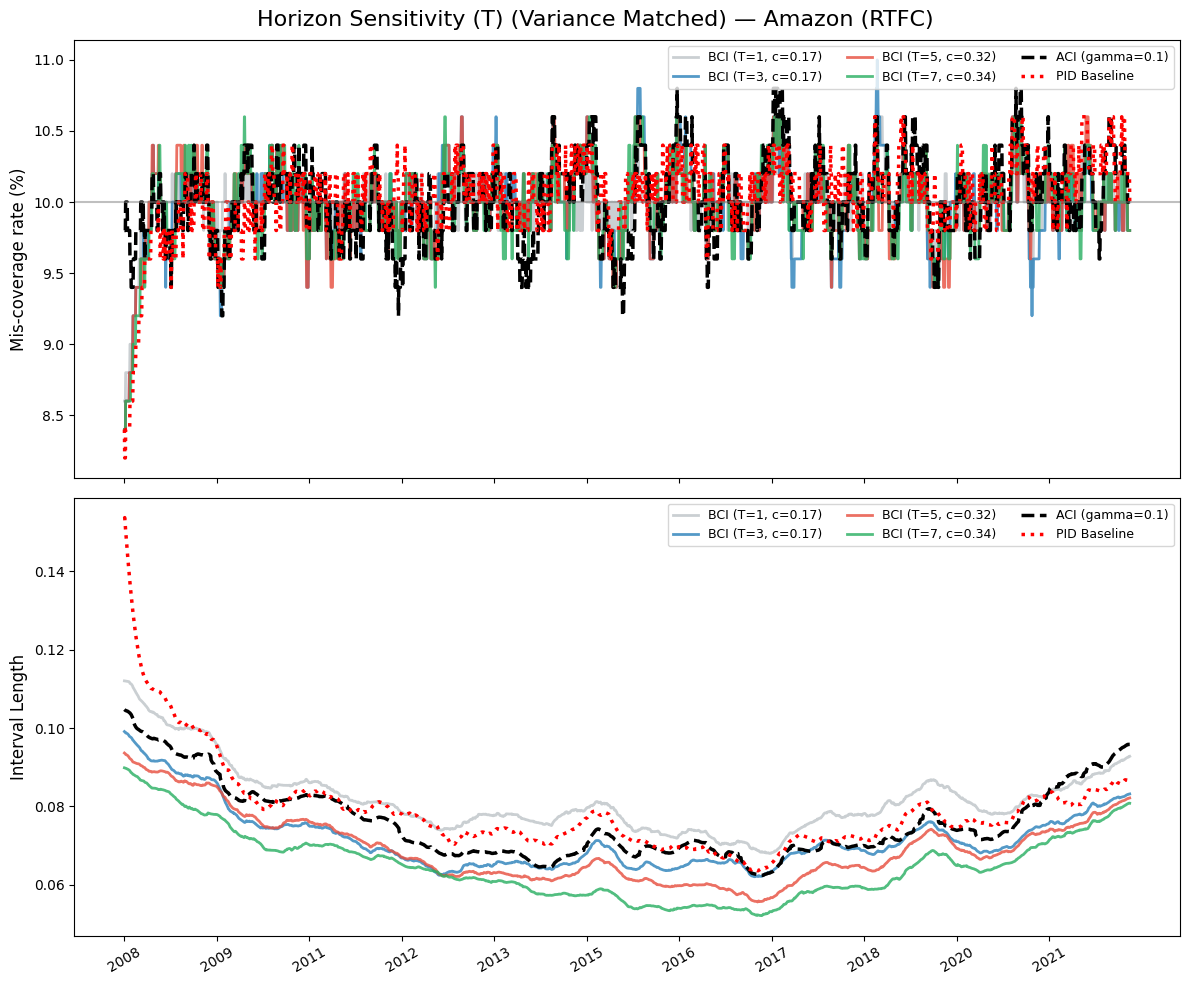



Table 1: gamma = 0.1, T Sweep (Variance Matched)
Method               Tuned Params    Miscoverage %   Volatility (Std %)   Avg Length  
-------------------------------------------------------------------------------------
ACI (gamma=0.1)      -               9.97          % 2.71               % 0.0796      
PID                  eta=0.323       9.86          % 2.71               % 0.0870      
BCI (T=1)            c=0.168         9.81          % 2.06               % 0.0849      
BCI (T=3)            c=0.167         9.78          % 2.99               % 0.0745      
BCI (T=5)            c=0.316         9.78          % 2.74               % 0.0716      
BCI (T=7)            c=0.345         9.78          % 2.78               % 0.0674      


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import logging
from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

# Silence the verbose logging during tuning to keep the terminal clean
logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

# =============================================================================
# 1. HELPER FUNCTIONS & METRICS
# =============================================================================

def clean_config(config):
    """Removes list brackets from YAML (e.g., [0.1] -> 0.1) to avoid math errors."""
    new_config = config.copy()
    for key, value in new_config.items():
        if isinstance(value, list):
            new_config[key] = value[0]
    return new_config

def compute_metrics(result_df, task='rtfc'):
    """Calculates final metrics, ignoring the initial burn-in period."""
    alpha = pd.to_numeric(result_df['alpha'], errors='coerce')
    beta  = pd.to_numeric(result_df['beta'],  errors='coerce')
    upper = pd.to_numeric(result_df['upper'], errors='coerce')
    lower = pd.to_numeric(result_df['lower'], errors='coerce')

    err_ind = (alpha > beta).astype(float)
    local_miscov = err_ind.rolling(window=50, min_periods=1).mean()
    
    std = local_miscov.std()
    miscov = err_ind.mean()

    if task == 'vlfc':
        raw_lengths = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    else:
        raw_lengths = upper - lower

    valid = raw_lengths[np.isfinite(raw_lengths)]
    length = valid.mean() if len(valid) > 0 else np.nan
    return float(miscov), float(std), float(length)

def compute_initial_miscov(result_df, window=100):
    """Calculates miscoverage during the first 'window' steps (Transient phase)."""
    df = result_df.iloc[:window].copy()
    alpha = pd.to_numeric(df['alpha'], errors='coerce')
    beta = pd.to_numeric(df['beta'], errors='coerce')
    return (alpha > beta).astype(float).mean()

def clean_df(df):
    """Converts key columns to numeric to ensure gen_plot_data doesn't crash."""
    for col in ['upper', 'lower', 'true_y', 'alpha', 'beta']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def estimate_lambda_max(task, dataset, warmup=100):
    try:
        cfg = read_yaml(f'config/{task}-bci-{dataset}.yaml')
    except FileNotFoundError:
        cfg = read_yaml(f'config/{task}-bci.yaml')
        cfg['id'] = dataset
        
    cfg = clean_config(cfg)
    exp = ForecastingExperiment(cfg)
    exp.run()
    
    lambdas = pd.to_numeric(exp.result['lambda'], errors='coerce').dropna()
    vals = lambdas.values[:warmup] if len(lambdas) >= warmup else lambdas.values
    return float(max(np.percentile(vals, 99), 1.0))

# =============================================================================
# 2. TUNING LOGIC (BINARY SEARCHES)
# =============================================================================

def tune_lambda_init(bci_config, target_miscov, max_iter=12):
    lo, hi = 1e-4, 1e4
    best_lam = float(bci_config.get('lambda_init', 5.0))
    for _ in range(max_iter):
        mid = np.sqrt(lo * hi)
        cfg = dict(bci_config)
        cfg['lambda_init'] = float(mid)
        exp = ForecastingExperiment(cfg)
        exp.fcdata.expectancy = lambda: 110 # SPEED HACK
        exp.run()
        init_miscov = compute_initial_miscov(exp.result, window=100)
        if init_miscov > target_miscov: lo = mid
        else: hi, best_lam = mid, mid
    return best_lam

def binary_search_bci_c(bci_config, lambda_max, target_std, task, max_iter=15):
    target_var = target_std ** 2
    lo, hi = 0.001, 2.0
    best_c = lo
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        cfg = dict(bci_config)
        cfg['gamma'] = float(mid * lambda_max)
        exp = ForecastingExperiment(cfg)
        exp.fcdata.expectancy = lambda: 1000 # SPEED HACK
        
        from utils.dp import DynamicConformal
        original_dp = DynamicConformal.dp
        DynamicConformal.dp = lambda self, bins: original_dp(self, bins=50) # SPEED HACK
        exp.run()
        DynamicConformal.dp = original_dp
        
        _, current_std, _ = compute_metrics(exp.result, task)
        if (current_std**2) > target_var: lo = mid
        else: hi, best_c = mid, mid
    return best_c

def binary_search_pid(scores, y_pred_center, y_true, csat, ki, target_std, task):
    target_var = target_std ** 2
    lo, hi = 1e-6, 5 * np.percentile(scores, 99)
    best_eta = lo
    for _ in range(20): 
        mid = np.sqrt(lo * hi)
        try:
            pid_out = quantile_integrator_log(scores=scores, alpha=0.1, lr=mid, Csat=csat, KI=ki, ahead=1, T_burnin=100)
            q = np.maximum(np.array(pid_out['q']), 0.0)
            y_u = (y_pred_center + q)**2 if task == 'vlfc' else (y_pred_center + q)
            y_l = np.maximum(y_pred_center - q, 0)**2 if task == 'vlfc' else (y_pred_center - q)
            var = pd.Series((~( (y_true >= y_l) & (y_true <= y_u) )).astype(float)).rolling(window=50, min_periods=1).mean().var()
            if var > target_var: lo = mid
            else: hi, best_eta = mid, mid
        except: hi = mid
    return best_eta

# =============================================================================
# 3. MAIN PIPELINE
# =============================================================================

if __name__ == "__main__":
    task, dataset, base_gamma, T_vals = 'rtfc', 'Amazon', 0.1, [1, 3, 5, 7]
    xform = lambda x: x.astype(float)
    
    # Plot Setup
    fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    colors = ['#bdc3c7', '#2980b9', '#e74c3c', '#27ae60']
    
    print(f"\n--- STEP 1: INITIALIZING BASELINES ({dataset}) ---")
    
    # A. Fixed Model
    cfg_fix = clean_config(read_yaml(f'config/{task}-fixed-{dataset}.yaml'))
    exp_fix = ForecastingExperiment(cfg_fix); exp_fix.run()
    y_true = pd.to_numeric(exp_fix.result['true_y'], errors='coerce').values
    u_f, l_f = pd.to_numeric(exp_fix.result['upper']).values, pd.to_numeric(exp_fix.result['lower']).values
    y_pred_center = (u_f + l_f) / 2
    scores = np.abs(y_true - y_pred_center)

    # B. ACI Target Model
    cfg_aci = clean_config(read_yaml(f'config/{task}-aci-{dataset}.yaml'))
    cfg_aci['gamma'] = base_gamma
    exp_aci = ForecastingExperiment(cfg_aci); exp_aci.run()
    aci_m, aci_s, aci_l = compute_metrics(exp_aci.result, task)
    p_aci = gen_plot_data(clean_df(exp_aci.result.copy()), 250, 300, xform)

    # C. PID Calibrated Model
    T_len, ki = len(scores), np.percentile(scores, 99)
    csat = max((2 / np.pi) * (np.ceil(np.log(T_len) * 0.05) - 1 / np.log(T_len)), 0.1)
    best_eta = binary_search_pid(scores, y_pred_center, y_true, csat, ki, aci_s, task)
    pid_out = quantile_integrator_log(scores, 0.1, best_eta, csat, ki, 1, 100)
    q_pid = np.maximum(np.array(pid_out['q']), 0.0)
    df_pid = exp_fix.result.copy()
    df_pid['upper'], df_pid['lower'], df_pid['alpha'] = y_pred_center + q_pid, y_pred_center - q_pid, 0.1
    df_pid['beta'] = ((y_true >= df_pid['lower']) & (y_true <= df_pid['upper'])).astype(int)
    pid_m, pid_s, pid_l = compute_metrics(df_pid, task)
    pid_init_miscov = compute_initial_miscov(df_pid)
    p_pid = gen_plot_data(clean_df(df_pid.copy()), 250, 300, xform)

    # --- STEP 2: BCI HORIZON SWEEP ---
    print(f"--- STEP 2: RUNNING BCI HORIZON SWEEP ---")
    l_max = estimate_lambda_max(task, dataset)
    base_bci_cfg = clean_config(read_yaml(f'config/{task}-bci-{dataset}.yaml'))
    
    table_results = [
        [f"ACI (gamma={base_gamma})", "-", aci_m*100, aci_s*100, aci_l],
        ["PID", f"eta={best_eta:.3f}", pid_m*100, pid_s*100, pid_l]
    ]

    last_p = None
    for i, t_val in enumerate(T_vals):
        print(f"\n   --- Processing BCI (T={t_val}) ---")
        cfg = dict(base_bci_cfg); cfg['lambda_max'], cfg['T'] = float(l_max), t_val
        
        best_c = binary_search_bci_c(cfg, l_max, aci_s, task)
        cfg['gamma'] = float(best_c * l_max)
        
        best_li = tune_lambda_init(cfg, pid_init_miscov)
        cfg['lambda_init'] = float(best_li)
        print(f"   -> Tuned c: {best_c:.4f}, Tuned lambda_init: {best_li:.4f}")
        
        exp = ForecastingExperiment(cfg); exp.run()
        m, s, l = compute_metrics(exp.result, task)
        table_results.append([f"BCI (T={t_val})", f"c={best_c:.3f}", m*100, s*100, l])

        # Plot Data Generation
        p = gen_plot_data(clean_df(exp.result.copy()), 250, 300, xform)
        last_p = p
        axs[0].plot(100*p['miscovrate'], color=colors[i], label=f'BCI (T={t_val}, c={best_c:.2f})', linewidth=2.0, alpha=0.8)
        axs[1].plot(p['length'], color=colors[i], label=f'BCI (T={t_val}, c={best_c:.2f})', linewidth=2.0, alpha=0.8)

    # =========================================================================
    # 4. FINAL VISUALS & TABLE
    # =========================================================================
    axs[0].plot(100*p_aci['miscovrate'], color='black', label=f'ACI (gamma={base_gamma})', linewidth=2.5, linestyle='--')
    axs[1].plot(p_aci['length'], color='black', label=f'ACI (gamma={base_gamma})', linewidth=2.5, linestyle='--')
    
    axs[0].plot(100*p_pid['miscovrate'], color='red', label='PID Baseline', linewidth=2.5, linestyle=':')
    axs[1].plot(p_pid['length'], color='red', label='PID Baseline', linewidth=2.5, linestyle=':')

    axs[0].axhline(10, color='gray', linestyle='-', alpha=0.5)
    axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=12)
    axs[0].legend(frameon=True, prop={'size': 9}, ncol=3, loc='upper right')
    
    axs[1].set_ylabel('Interval Length', fontsize=12)
    axs[1].legend(frameon=True, prop={'size': 9}, ncol=3, loc='upper right')
    
    if last_p:
        axs[1].set_xticks(last_p['indices'])
        axs[1].set_xticklabels([last_p['date_indices'][j] for j in last_p['indices']], rotation=30, fontsize=10)

    plt.suptitle(f'Horizon Sensitivity (T) (Variance Matched) — {dataset} ({task.upper()})', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

    print(f"\n\n{'='*85}\nTable 1: gamma = {base_gamma}, T Sweep (Variance Matched)\n{'='*85}")
    print(f"{'Method':<20} {'Tuned Params':<15} {'Miscoverage %':<15} {'Volatility (Std %)':<20} {'Avg Length':<12}")
    print("-" * 85)
    for row in table_results:
        print(f"{row[0]:<20} {row[1]:<15} {row[2]:<14.2f}% {row[3]:<19.2f}% {row[4]:<12.4f}")